# <font color='blue'> Titanic Survival Prediction </font>

The dataset for this study is a modified version of the original Titanic dataset from Kaggle, specifically preprocessed for binary logistic regression modeling.

## <font color='purple'> Description of Dataset </font>

This dataset contains passenger information from the Titanic, structured to predict survival outcomes using binary classification. The data has undergone several preprocessing and feature engineering steps to optimize it for logistic regression:

* **Data Integration:** The original train and test datasets were merged into a single comprehensive dataset.
* **Feature Selection:** Attributes with high cardinality or excessive missing values, specifically `'ticket'` and `'cabin'`, were removed.
* **Target Variable Realignment:** The response variable `'Survived'` was relocated to the final column of the dataset.
* **Categorical Preparation:** Additional placeholder columns of zeros were incorporated to facilitate One-Hot Encoding for categorical variables.
* **Data Transformation:** The `'Sex'` attribute was converted to binary values, while the `'Embarked'` attribute was mapped to categorical numerical representations.
* **Imputation:** Missing values in the `'Age'` and `'Fare'` attributes were handled by filling them with the median value of the respective features.

Given the nature of the classification task, appropriate evaluation metrics such as ROC-AUC, Precision, Recall, and the Confusion Matrix should be utilized to assess model performance effectively.

### <font color='blue'> Data Columns </font>

1. **Pclass:** Passenger Class (1st, 2nd, 3rd)
2. **Name:** Passenger Name
3. **Sex:** Gender (converted to binary values)
4. **Age:** Passenger Age (missing values imputed with the median)
5. **SibSp:** Number of Siblings / Spouses Aboard
6. **Parch:** Number of Parents / Children Aboard
7. **Fare:** Passenger Fare (missing values imputed with the median)
8. **Embarked:** Port of Embarkation (converted to categorical values)
9. **Survived:** Response variable (1 for survived, 0 otherwise; positioned as the final column)

## <font color='orange'> Loading Data and Pre-processing </font>

In [1]:
# load the data
import pandas as pd

df = pd.read_csv("../data/titanic.xls")
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [2]:
# check for null entries

null_columns = df.isnull().sum()
print(null_columns)

df.info()

Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
zero           0
zero.1         0
zero.2         0
zero.3         0
zero.4         0
zero.5         0
zero.6         0
Parch          0
zero.7         0
zero.8         0
zero.9         0
zero.10        0
zero.11        0
zero.12        0
zero.13        0
zero.14        0
Pclass         0
zero.15        0
zero.16        0
Embarked       2
zero.17        0
zero.18        0
2urvived       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non

In [3]:
# data description
df.describe()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.0,1309.0,1309.0,1309.0,1309.0,...,1309.0,1309.0,1309.0,1309.000000,1309.0,1309.0,1307.000000,1309.0,1309.0,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.294882,0.0,0.0,1.492731,0.0,0.0,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.837836,0.0,0.0,0.814626,0.0,0.0,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.000000,0.0,0.0,1.000000,0.0,0.0,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000


## <font color='orange'> Distribution of Variables </font>

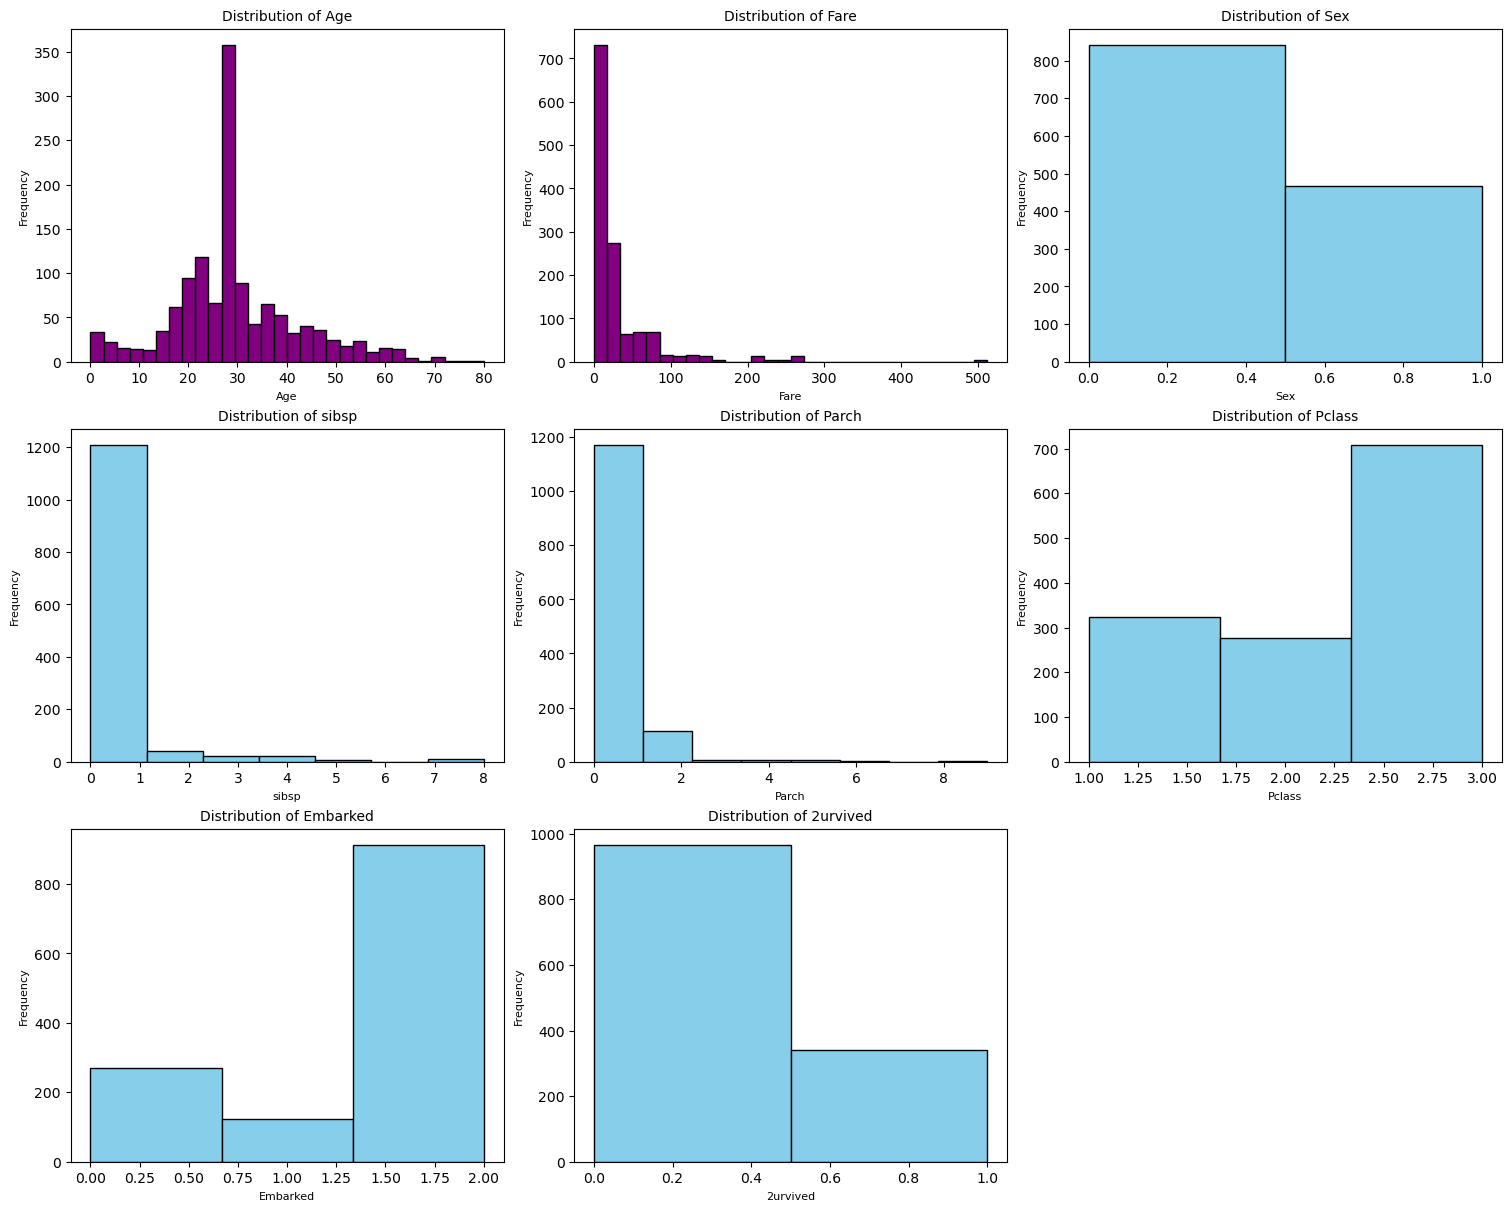

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming your dataframe is named 'df'
# Example: df = pd.read_csv('your_dataset.csv')

# Remove all columns that contain 'zero' in their name, as well as 'Passengerid'
columns_to_plot = [
    col
    for col in df.columns
    if "zero" not in col.lower() and col != "Passengerid"
]

# Set up the plotting parameters based on the remaining columns
# Remaining columns: Age, Fare, Sex, sibsp, Parch, Pclass, Embarked, 2urvived (total 8 columns)
fig, axes = plt.subplots(
    nrows=3, ncols=3, figsize=(15, 12), constrained_layout=True
)
axes = axes.flatten()

# Generate histograms/distributions for each filtered column
for i, col in enumerate(columns_to_plot):
    if i < len(axes):
        # Drop null values for plotting to avoid errors
        data_to_plot = df[col].dropna()

        # Check if the column is binary/categorical
        if data_to_plot.nunique() <= 10:
            axes[i].hist(
                data_to_plot,
                bins=data_to_plot.nunique(),
                color="skyblue",
                edgecolor="black",
                align="mid",
            )
        else:
            axes[i].hist(
                data_to_plot, bins=30, color="purple", edgecolor="black"
            )

        axes[i].set_title(f"Distribution of {col}", fontsize=10)
        axes[i].set_xlabel(col, fontsize=8)
        axes[i].set_ylabel("Frequency", fontsize=8)

# Hide any unused subplots if the grid is larger than the number of columns
for j in range(len(columns_to_plot), len(axes)):
    fig.delaxes(axes[j])

# Save the figure as PDF and PNG
plt.savefig(
    "../figures/titanic_filtered_variables_distribution.png", dpi=300, bbox_inches="tight"
)
plt.savefig("../figures/titanic_filtered_variables_distribution.pdf", bbox_inches="tight")

# Display the plots
plt.show()

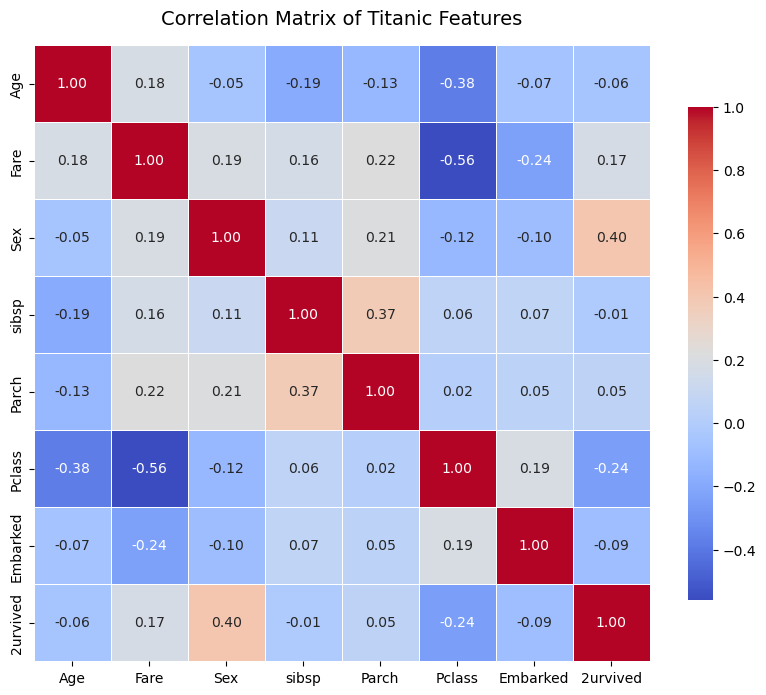

In [7]:
import seaborn as sns

# Assuming your dataframe is named 'df'
# Example: df = pd.read_csv('your_dataset.csv')

# Remove all columns that contain 'zero' in their name, as well as 'Passengerid'
columns_for_corr = [
    col
    for col in df.columns
    if "zero" not in col.lower() and col != "Passengerid"
]

# Filter the dataframe for the selected variables
df_corr = df[columns_for_corr]

# Calculate the correlation matrix
corr_matrix = df_corr.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap using Seaborn
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

# Set the title
plt.title("Correlation Matrix of Titanic Features", fontsize=14, pad=15)

# Save the figure as PNG and PDF
plt.savefig("../figures/titanic_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.savefig("../figures/titanic_correlation_matrix.pdf", bbox_inches="tight")

# Display the plot
plt.show()